# Imports

In [1]:
# Imports

#Pytorch
import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.utils.data as data

#Others
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

from abc import abstractmethod

# Functions

## Membership Functions

In [2]:
class MembershipFunction(nn.Module):
    def __init__(self):
        super(MembershipFunction, self).__init__()
        self._params = None
        self._simple_implementation = None # Simple numpy implementation needed for plotting
        
    @abstractmethod
    def forward(self, x, premises):
        pass
    
    @abstractmethod
    def initialize_premises(self):
        pass

In [3]:

class Gaussian_MF(MembershipFunction):
    def __init__(self):
        super(Gaussian_MF, self).__init__()
        self._params = ["mu", "sigma"]
        self._simple_implementation = lambda x, mu, sigma: np.exp(-0.5 * np.power((x - mu)/sigma, 2))

    def forward(self, x, premises):
        return torch.exp(-0.5 * torch.pow((x.unsqueeze(x.dim()) - premises[:, :, 0])/torch.where(premises[:, :, 1] == 0, torch.tensor(1e-6), premises[:, :, 1]), 2))

    def initialize_premises(self, x_train, fuzzy_rules):
        input_size = x_train.shape[1]
        premises = torch.zeros(input_size, fuzzy_rules, len(self._params), dtype=x_train.dtype)
        
        if fuzzy_rules > 1:
            min = torch.min(x_train, dim=0).values
            max = torch.max(x_train, dim=0).values
            stp = (max - min) / (fuzzy_rules - 1)
            for i in range(input_size):
                h = torch.arange(min[i], max[i] + stp[i], stp[i])
                premises[i, :, 0] = h[:fuzzy_rules]
                premises[i, :, 1] = stp[i]/2
        else:
            for i in range(input_size):
                premises[i, :, 0] = torch.mean(x_train[:, i])
                premises[i, :, 1] = torch.std(x_train[:, i])
                
        return premises

In [4]:

class GeneralizedBell_MF(MembershipFunction):
    def __init__(self):
        super(GeneralizedBell_MF, self).__init__()
        self._params = ["a", "b", "c"] # ["width", "slope", "center"]
        self._simple_implementation = lambda x, a, b, c: 1/(1 + np.power(np.abs((x - c)/a), 2*b))

    def forward(self, x, premises):
        return 1/(1 + torch.pow(torch.abs((x.unsqueeze(x.dim()) - premises[:, :, 2])/torch.where(premises[:, :, 0] == 0, torch.tensor(1e-6), premises[:, :, 0])), 2*premises[:, :, 1]))

    def initialize_premises(self, x_train, fuzzy_rules):
        input_size = x_train.shape[1]
        premises = torch.zeros(input_size, fuzzy_rules, len(self._params), dtype=x_train.dtype)
        
        if fuzzy_rules > 1:
            min = torch.min(x_train, dim=0).values
            max = torch.max(x_train, dim=0).values
            stp = (max - min) / (fuzzy_rules - 1)
            for i in range(input_size):
                h = torch.arange(min[i], max[i] + stp[i], stp[i])
                premises[i, :, 2] = h[:fuzzy_rules]
                premises[i, :, 0] = stp[i]/2
                premises[i, :, 1] = 8
        else:
            for i in range(input_size):
                premises[i, :, 2] = torch.mean(x_train[:, i])
                premises[i, :, 0] = torch.std(x_train[:, i])
                premises[i, :, 1] = 8
                
        return premises

## Consequent Functions

In [5]:
class ConsequentFunction(nn.Module):
    @abstractmethod
    def forward(self, x, consequents, weights):
        pass
    
    @abstractmethod
    def initialize_consequents(self, outputs, consequents_rules, input_size, input_dtype):
        pass

In [6]:
class Linear_CF(ConsequentFunction):

    def forward(self, x, consequents, weights):
        return (torch.bmm(x.unsqueeze(0).expand(consequents[:, :, :-1].size(0), -1, -1), torch.transpose(consequents[:, :, :-1], 1, 2)) + consequents[:, :, -1].unsqueeze(1)).mul(weights.unsqueeze(0))

    def initialize_consequents(self, outputs, consequents_rules, input_size, input_dtype):
        return 2 * torch.rand(outputs, consequents_rules, input_size + 1, dtype=input_dtype) - 1

In [7]:
class Quadratic_CF(ConsequentFunction):

    def forward(self, x, consequents, weights):
        x_ext = torch.cat((x, x ** 2), dim=-1)
        
        # Calcula la suma ponderada cuadrática
        output = (torch.bmm(x_ext.unsqueeze(0).expand(consequents[:, :, :-1].size(0), -1, -1), 
                            torch.transpose(consequents[:, :, :-1], 1, 2)) + 
                  consequents[:, :, -1].unsqueeze(1)).mul(weights.unsqueeze(0))
        
        return output
    
    def initialize_consequents(self, outputs, consequents_rules, input_size, input_dtype):
        return 2 * torch.rand(outputs, consequents_rules, 2 * input_size + 1, dtype=input_dtype) - 1

## Testing

In [8]:
fun = Linear_CF()

x = torch.tensor([[ 1.1450,  0.2033],
                  [ 0.8449, -0.3250],
                  [-0.9504, -0.2198],
                  [ 0.4151,  0.4604],
                  [ 1.4029,  1.8295]])

w = torch.tensor([[8.5932e-10, 3.3908e-04, 2.0990e-08],
                  [1.7680e-08, 4.7126e-06, 1.6303e-10],
                  [1.0000e+00, 1.2051e-09, 1.2076e-19],
                  [3.3648e-09, 9.9994e-01, 8.2564e-11],
                  [5.4210e-20, 2.3282e-10, 1.0000e+00]])

c = torch.tensor([[[0.8250, 0.2573, 0.0918],
                   [0.3520, 0.8469, 0.8391],
                   [0.4386, 0.1846, 0.3082]]])

In [9]:
fun(x, c, w)

tensor([[[ 9.3557e-10,  4.7957e-04,  1.7798e-08],
         [ 1.2468e-08,  4.0588e-06,  1.0088e-10],
         [-7.4883e-01,  3.8372e-10, -1.8020e-20],
         [ 1.8598e-09,  1.3750e+00,  4.7495e-11],
         [ 9.3237e-20,  6.7106e-10,  1.2612e+00]]])

In [10]:
'''
        consequents:
            ([[[c11, c12, c13, c14, c15],
               [c21, c22, c23, c24, c25],
               [c31, c32, c33, c34, c35]]])
        
        sum1 = ({(x1 * c11) + (x2 * c12)} + {(x1**2 * c13) + (x2**2 * c14)} + c15) * w1
        sum2 = ({(x1 * c21) + (x2 * c22)} + {(x1**2 * c23) + (x2**2 * c24)} + c25) * w2
        sum3 = ({(x1 * c31) + (x2 * c32)} + {(x1**2 * c33) + (x2**2 * c34)} + c35) * w3
        
        concept:
                x1   x2   x3  | x1**2  x2**2  x3**2 |  1
            ([[[c11, c12, c13 | c14,   c15,   c16   | c17],
               [c21, c22, c23 | c24,   c25    c26   | c27],
               [c31, c32, c33 | c34,   c35    c36   | c37]]])
'''

'\n        consequents:\n            ([[[c11, c12, c13, c14, c15],\n               [c21, c22, c23, c24, c25],\n               [c31, c32, c33, c34, c35]]])\n        \n        sum1 = ({(x1 * c11) + (x2 * c12)} + {(x1**2 * c13) + (x2**2 * c14)} + c15) * w1\n        sum2 = ({(x1 * c21) + (x2 * c22)} + {(x1**2 * c23) + (x2**2 * c24)} + c25) * w2\n        sum3 = ({(x1 * c31) + (x2 * c32)} + {(x1**2 * c33) + (x2**2 * c34)} + c35) * w3\n        \n        concept:\n                x1   x2   x3  | x1**2  x2**2  x3**2 |  1\n            ([[[c11, c12, c13 | c14,   c15,   c16   | c17],\n               [c21, c22, c23 | c24,   c25    c26   | c27],\n               [c31, c32, c33 | c34,   c35    c36   | c37]]])\n'

In [11]:
fun = Quadratic_CF()

x = torch.tensor([[ 10.,  20.],
                  [ 0.8449, -0.3250],
                  [-0.9504, -0.2198],
                  [ 0.4151,  0.4604],
                  [ 1.,  2.]])

w = torch.tensor([[6., 3.3908e-04, 2.0990e-08],
                  [1.7680e-08, 4.7126e-06, 1.6303e-10],
                  [1.0000e+00, 1.2051e-09, 1.2076e-19],
                  [3.3648e-09, 9.9994e-01, 8.2564e-11],
                  [5.4210e-20, 3., 1.0000e+00]])

c = torch.tensor([[[1., 2., 3., 4., 5.],
                   [10, 20, 30, 40, 50],
                   [0.4386, 0.1846, 0.3082, 0.2573, 0.2573]]])

In [13]:
fun(x, c, w)

tensor([[[1.1730e+04, 6.6290e+00, 2.9822e-06],
         [1.3718e-07, 3.6565e-04, 1.3288e-10],
         [6.5130e+00, 7.8489e-08, 1.0952e-20],
         [2.5911e-08, 7.7002e+01, 5.2180e-11],
         [1.5721e-18, 8.7000e+02, 2.4025e+00]]])

# ANFIS

## Layers

### Layer 1: Fuzzify

In [107]:

class FuzzifyLayer(nn.Module):
    
    def __init__(self, x_train, init_fuzzy_rules=1, membership_function=GeneralizedBell_MF, init_mode=0):
        super(FuzzifyLayer, self).__init__()
        # Input data info
        self._input_size = x_train.shape[1]
        self._dtype = x_train.dtype
        self._max_val = (torch.sign(torch.max(x_train)) * torch.ceil(torch.abs(torch.max(x_train)))).item()
        self._min_val = (torch.sign(torch.min(x_train)) * torch.ceil(torch.abs(torch.min(x_train)))).item()
        
        # Initialize membership function
        self._membership_function = membership_function()

        # Initialize premise parameters
        if init_mode == 0: # Based on data
            self._premises = Parameter(self._membership_function.initialize_premises(x_train=x_train, fuzzy_rules=init_fuzzy_rules), requires_grad=True)
        else: # Random initialization
            self._premises = Parameter(2 * torch.rand(self._input_size, init_fuzzy_rules, len(self._membership_function._params), dtype=self._dtype) - 1, requires_grad=True)



    def forward(self, x):
        return self._membership_function(x, self._premises)



    @property
    def premises_structure(self):
        df = pd.DataFrame()
        rules = ['Fuzzy rule {}'.format(i) for i in range(1, self._premises.data.shape[1]+1)]
        
        for i in range(self._input_size):
            for j in range(len(self._membership_function._params)):
                column = pd.Series(self._premises.data[i,:,j], index=rules, name=self._membership_function._params[j] + f' (x{i})', )
                df[self._membership_function._params[j] + f' (x{i})'] = column

        return df



    @property
    def plot_premises(self):
        variables = [f'x{i}' for i in range(self._input_size)]
        dataframe = self.premises_structure

        sep = round((0.1 * (self._max_val - self._min_val))) + 1
        x = np.linspace(self._min_val - sep, self._max_val + sep, 500)

        fig, axes = plt.subplots(nrows=self._premises.data.shape[1], ncols=len(variables), figsize=(15, 8), sharex=False, sharey=False)

        if not isinstance(axes, np.ndarray):
            axes = np.array([[axes]])

        for i, rule in enumerate(dataframe.index):
            for j, var in enumerate(variables):
                params = [dataframe.loc[rule, f'{param} ({var})'] for param in self._membership_function._params]
                
                y = self._membership_function._simple_implementation(x, *params)

                ax = axes[i, j] if axes.ndim > 1 else axes[max(i, j)]
                ax.plot(x, y, label=f'{rule}, {var}')
                ax.set_title(f'{rule}, {var}')
                ax.grid(True)
                if i == self._premises.data.shape[1] - 1:
                    ax.set_xlabel('x')
                if j == 0:
                    ax.set_ylabel('Membership Value')

        plt.tight_layout()
        plt.show()

In [108]:
class otherFuzzifyLayer(nn.Module):
    
    def __init__(self, input_size, init_fuzzy_rules=1, membership_function=GeneralizedBell_MF, dtype=torch.float32):
        super(otherFuzzifyLayer, self).__init__()
        # Input data info
        self._input_size = input_size
        
        # Initialize membership function
        self._membership_function = membership_function()

        # Initialize random premise parameters
        self._premises = Parameter(2 * torch.rand(self._input_size, init_fuzzy_rules, len(self._membership_function._params), dtype=dtype) - 1, requires_grad=True)



    def forward(self, x):
        return self._membership_function(x, self._premises)



    def init_premises(self, x_train):
        self._premises = Parameter(self._membership_function.initialize_premises(x_train=x_train, fuzzy_rules=self._premises.shape[1]), requires_grad=True)



    @property
    def premises_structure(self):
        df = pd.DataFrame()
        rules = ['Fuzzy rule {}'.format(i) for i in range(1, self._premises.data.shape[1]+1)]
        
        for i in range(self._input_size):
            for j in range(len(self._membership_function._params)):
                column = pd.Series(self._premises.data[i,:,j], index=rules, name=self._membership_function._params[j] + f' (x{i})', )
                df[self._membership_function._params[j] + f' (x{i})'] = column

        return df


    
    def plot_premises(self):
        variables = [f'x{i}' for i in range(self._input_size)]
        dataframe = self.premises_structure

        fig, axes = plt.subplots(nrows=self._premises.data.shape[1], ncols=len(variables), figsize=(15, 8), sharex=True, sharey=True)

        if not isinstance(axes, np.ndarray):
            axes = np.array([[axes]])

        for i, rule in enumerate(dataframe.index):
            for j, var in enumerate(variables):
                params = [dataframe.loc[rule, f'{param} ({var})'] for param in self._membership_function._params]
                
                a = params[0]
                c = params[2]
                
                x = np.linspace(c - 2*a, c + 2*a, 500)
                
                y = self._membership_function._simple_implementation(x, *params)

                ax = axes[i, j] if axes.ndim > 1 else axes[max(i, j)]
                ax.plot(x, y, label=f'{rule}, {var}')
                ax.set_title(f'{rule}, {var}')
                ax.grid(True)
                if i == self._premises.data.shape[1] - 1:
                    ax.set_xlabel('x')
                if j == 0:
                    ax.set_ylabel('Membership Value')

        plt.tight_layout()
        plt.show()

#### Testing

In [109]:
x_train = torch.randn(5, 2)
x_train

tensor([[-1.5448, -0.0267],
        [ 1.1864,  0.3187],
        [-0.2514,  0.6782],
        [ 0.8236, -0.9601],
        [-0.2726,  2.0461]])

In [110]:
layer1 = FuzzifyLayer(x_train, init_fuzzy_rules=3, membership_function=GeneralizedBell_MF)

In [111]:
layer1.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 1,0.682804,8.0,-1.544841,0.751558,8.0,-0.960095
Fuzzy rule 2,0.682804,8.0,-0.179232,0.751558,8.0,0.543021
Fuzzy rule 3,0.682804,8.0,1.186377,0.751558,8.0,2.046137


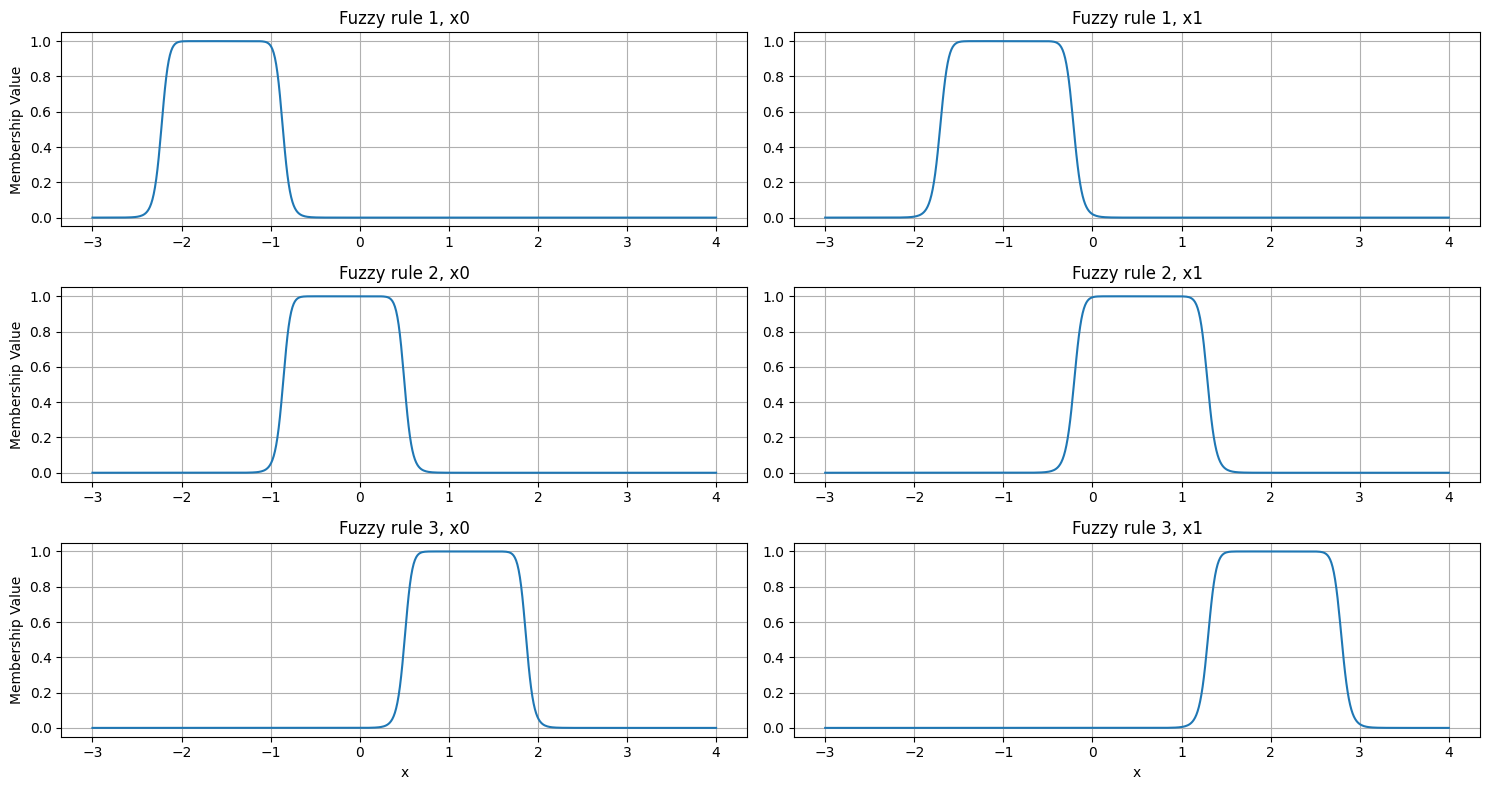

In [112]:
layer1.plot_premises

In [113]:
output_1 = layer1(x_train)
output_1.shape

torch.Size([5, 2, 3])

In [114]:
other_layer1 = otherFuzzifyLayer(input_size=2, init_fuzzy_rules=3, membership_function=GeneralizedBell_MF)
other_layer1.init_premises(x_train)
other_layer1.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 1,0.682804,8.0,-1.544841,0.751558,8.0,-0.960095
Fuzzy rule 2,0.682804,8.0,-0.179232,0.751558,8.0,0.543021
Fuzzy rule 3,0.682804,8.0,1.186377,0.751558,8.0,2.046137


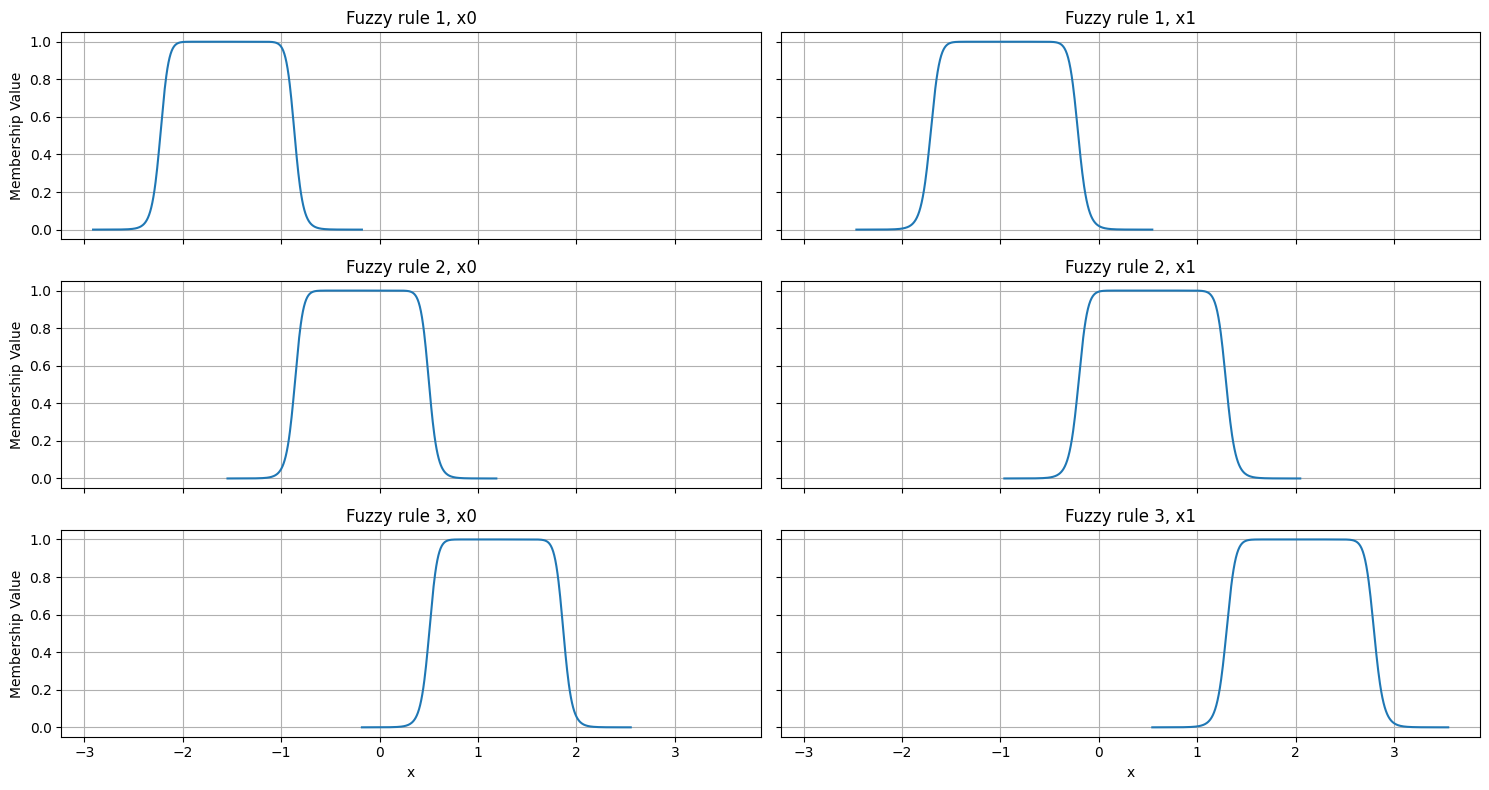

In [115]:
other_layer1.plot_premises()

### Layer 2: Firing Levels

In [116]:
'''
class FiringLevelsLayer(nn.Module):

    def forward(self, membership_values):
        w = torch.cat([torch.cartesian_prod(*torch.unbind(t, dim=0)).prod(dim=-1) for t in membership_values]).reshape(-1, membership_values.shape[-1]**membership_values.shape[-2])
        return w
        
class restrictedFiringLevelsLayer(nn.Module):

    def forward(self, membership_values):
        w = membership_values.prod(dim=membership_values.dim()-2)
        return w
'''

'\nclass FiringLevelsLayer(nn.Module):\n\n    def forward(self, membership_values):\n        w = torch.cat([torch.cartesian_prod(*torch.unbind(t, dim=0)).prod(dim=-1) for t in membership_values]).reshape(-1, membership_values.shape[-1]**membership_values.shape[-2])\n        return w\n        \nclass restrictedFiringLevelsLayer(nn.Module):\n\n    def forward(self, membership_values):\n        w = membership_values.prod(dim=membership_values.dim()-2)\n        return w\n'

In [117]:
class FiringLevelsLayer(nn.Module):
    def __init__(self, restricted=False):
        super(FiringLevelsLayer, self).__init__()
        self._restricted = restricted

    def forward(self, membership_values):
        if self._restricted:
            w = membership_values.prod(dim=membership_values.dim()-2)
        else:
            w = torch.cat([torch.cartesian_prod(*torch.unbind(t, dim=0)).prod(dim=-1) for t in membership_values]).reshape(-1, membership_values.shape[-1]**membership_values.shape[-2])
        return w

#### Testing

In [118]:
layer2 = FiringLevelsLayer(restricted=True)
output_2 = layer2(output_1)
output_2

tensor([[3.0256e-02, 1.5079e-05, 2.0773e-17],
        [4.7177e-14, 1.5259e-05, 1.6475e-06],
        [1.3987e-10, 1.0000e+00, 4.6149e-10],
        [2.2764e-09, 3.2467e-08, 2.3282e-10],
        [1.1037e-14, 1.5259e-05, 5.2943e-06]], grad_fn=<ProdBackward1>)

### Layer 3: Normalization

In [119]:
class NormalizationLayer(nn.Module):

    def forward(self, w):
        sum = torch.sum(w, dim=-1, keepdim=True)
        sum[sum == 0] = 1
        w = w/sum
        return w

#### Testing

In [120]:
layer3 = NormalizationLayer()
output_3 = layer3(output_2)
output_2, output_3

(tensor([[3.0256e-02, 1.5079e-05, 2.0773e-17],
         [4.7177e-14, 1.5259e-05, 1.6475e-06],
         [1.3987e-10, 1.0000e+00, 4.6149e-10],
         [2.2764e-09, 3.2467e-08, 2.3282e-10],
         [1.1037e-14, 1.5259e-05, 5.2943e-06]], grad_fn=<ProdBackward1>),
 tensor([[9.9950e-01, 4.9815e-04, 6.8623e-16],
         [2.7906e-09, 9.0255e-01, 9.7449e-02],
         [1.3987e-10, 1.0000e+00, 4.6149e-10],
         [6.5083e-02, 9.2826e-01, 6.6566e-03],
         [5.3698e-10, 7.4241e-01, 2.5759e-01]], grad_fn=<DivBackward0>))

### Layer 4: Consequent

In [121]:
class ConsequentLayer(nn.Module):
    
    def __init__(self, input_size, input_dtype, init_fuzzy_rules, consequent_function=Linear_CF, outputs=1, restricted=False):
        super(ConsequentLayer, self).__init__()
        # Initialize consequent function
        self._consequent_function = consequent_function()
        
        # Initialize consequent parameters
        if restricted:
            init_consequents_rules = init_fuzzy_rules
        else:
            init_consequents_rules = init_fuzzy_rules**input_size
            
        self._consequents = Parameter(self._consequent_function.initialize_consequents(outputs=outputs,
                                                                                       consequents_rules=init_consequents_rules, 
                                                                                       input_size=input_size, 
                                                                                       input_dtype=input_dtype), requires_grad=True)
        
    
    def forward(self, x, weights):
        return self._consequent_function(x, self._consequents, weights)
    
    
    @property
    def consequents_structure(self):
        dfs = [pd.DataFrame() for _ in range(self._consequents.data.shape[0])]

        rules = ['rule {}'.format(i) for i in range(1, self._consequents.data.shape[1]+1)]

        for o in range(self._consequents.data.shape[0]):
            for i in range(self._consequents.data.shape[2]):
                name=f'c{i} (x{i})'
                if (i == self._consequents.data.shape[2]-1): name=f'c{i}'
                column = pd.Series(self._consequents.data[o,:,i], index=rules, name=name)
                dfs[o][name] = column

        return dfs

#### Testing

In [122]:
layer4 = ConsequentLayer(input_size=x_train.shape[1], input_dtype=x_train.dtype, init_fuzzy_rules=3, consequent_function=Linear_CF, outputs=1, restricted=True)
layer4.consequents_structure

[         c0 (x0)   c1 (x1)        c2
 rule 1  0.846495 -0.538596 -0.487537
 rule 2 -0.843518 -0.125934  0.195209
 rule 3  0.117876 -0.930128 -0.108222]

In [123]:
output_4 = layer4(x_train, output_3)
output_4

tensor([[[-1.7800e+00,  7.4806e-04, -1.8220e-16],
         [ 9.6301e-10, -7.6324e-01, -2.5802e-02],
         [-1.4904e-10,  3.2183e-01, -3.5473e-10],
         [ 4.7300e-02, -3.5147e-01,  5.8703e-03],
         [-9.7750e-10,  1.2435e-01, -5.2640e-01]]], grad_fn=<MulBackward0>)

### Layer 5

In [124]:
class OutputLayer(nn.Module):
    def __init__(self, output_type):
        super(OutputLayer, self).__init__()
        _output_type = output_type.lower()
        
        if (_output_type == 'regression'):
            self._last_layer = nn.Identity()
        elif (_output_type == 'binary'):
            self._last_layer = nn.Sigmoid()
        elif (_output_type == 'multiclass'):
            self._last_layer = nn.Softmax(dim=1)

    def forward(self, x):
        x = torch.sum(x, dim=-1).t()
        return self._last_layer(x)

#### Testing

In [125]:
layer5 = OutputLayer(output_type='regression')
output_5 = layer5(output_4)
output_5

tensor([[-1.7792],
        [-0.7890],
        [ 0.3218],
        [-0.2983],
        [-0.4020]], grad_fn=<TBackward0>)

## ANFIS Implementation

In [126]:
class ANFIS(nn.Module):

    def __init__(self, x_train, init_fuzzy_rules=1, outputs=1, membership_function=GeneralizedBell_MF, consequent_function=Linear_CF, premises_init_mode=0, output_type=None, restricted=False):
        super(ANFIS, self).__init__()
        
        # Input data info
        self._input_size = x_train.shape[1]
        self._input_dtype = x_train.dtype
        
        
        # ANFIS info
        self._restricted = restricted
        self._outputs = outputs
        
        
        # Layers
        self._fuzzify_layer = FuzzifyLayer(x_train=x_train,
                                           init_fuzzy_rules=init_fuzzy_rules, 
                                           membership_function=membership_function, 
                                           init_mode=premises_init_mode)
        
        self._firing_levels_layer = FiringLevelsLayer(restricted=restricted)
        
        self._normalization_layer = NormalizationLayer()
        
        self._consequent_layer = ConsequentLayer(input_size=self._input_size, 
                                                 input_dtype=self._input_dtype, 
                                                 init_fuzzy_rules=init_fuzzy_rules, 
                                                 consequent_function=consequent_function, 
                                                 outputs=outputs,
                                                 restricted=restricted)
        
        self._output_layer = OutputLayer(output_type=output_type)    
    

    # ---- Forward pass ----
    def forward(self, x):
        output = self._fuzzify_layer(x)
        output = self._consequent_layer(x, self._normalization_layer(self._firing_levels_layer(output)))
        output = self._output_layer(output)
        return output
    
    
    
    # ---- Model predict ----
    def predict(self, x):
        output = self.forward(x).detach().numpy()
        
        if isinstance(self._output_layer._last_layer, nn.Softmax):
            output = np.argmax(output, axis=1, keepdims=True)
            
        elif isinstance(self._output_layer._last_layer, nn.Sigmoid):
            output = (output > 0.5).astype(int)
            
        return output
    

    # ---- Intermediate values ----
    def intermediate_values(self, x):
        with torch.no_grad():
            w = self._fuzzify_layer(x)
            w = self._firing_levels_layer(w)
            w_norm = self._normalization_layer(w)
        return w, w_norm
    
    
    # ----- Parameter seters and getters -----
    def set_premises(self, premises):
        self._fuzzify_layer._premises = Parameter(premises, requires_grad=True)
        
    def set_consequents(self, consequents):
        self._consequent_layer._consequents = Parameter(consequents, requires_grad=True)
        
    def get_premises(self):
        return self._fuzzify_layer._premises.data
    
    def get_consequents(self):
        return self._consequent_layer._consequents.data
    
    
    # ---- ANFIS rules info ----
    @property
    def fuzzy_rules(self):
        return self.get_premises().shape[1]
    
    @property
    def rules(self):
        return self.get_consequents().shape[1]
    
    
    # ----- Parameters dataframes -----
    @property
    def premises_structure(self):
        return self._fuzzify_layer.premises_structure
    
    @property
    def consequents_structure(self):
        return self._consequent_layer.consequents_structure
    
    
    # ----- Plot premises -----
    @property
    def plot_premises(self):
        self._fuzzify_layer.plot_premises

## Testing

### unANFIS

#### 1 output, regression

In [127]:
x_train = torch.randn(5, 2)
x_train

tensor([[-1.1044e-01,  1.4085e+00],
        [ 1.6647e-01, -1.8524e-01],
        [-8.3353e-04, -8.6451e-02],
        [ 1.5296e+00,  1.0776e+00],
        [-4.7500e-01,  8.1558e-01]])

In [128]:
anfis = ANFIS(x_train, 
              init_fuzzy_rules=3, 
              membership_function=GeneralizedBell_MF, 
              consequent_function=Linear_CF, 
              premises_init_mode=0, 
              outputs=1, 
              output_type='regression', 
              restricted=False)

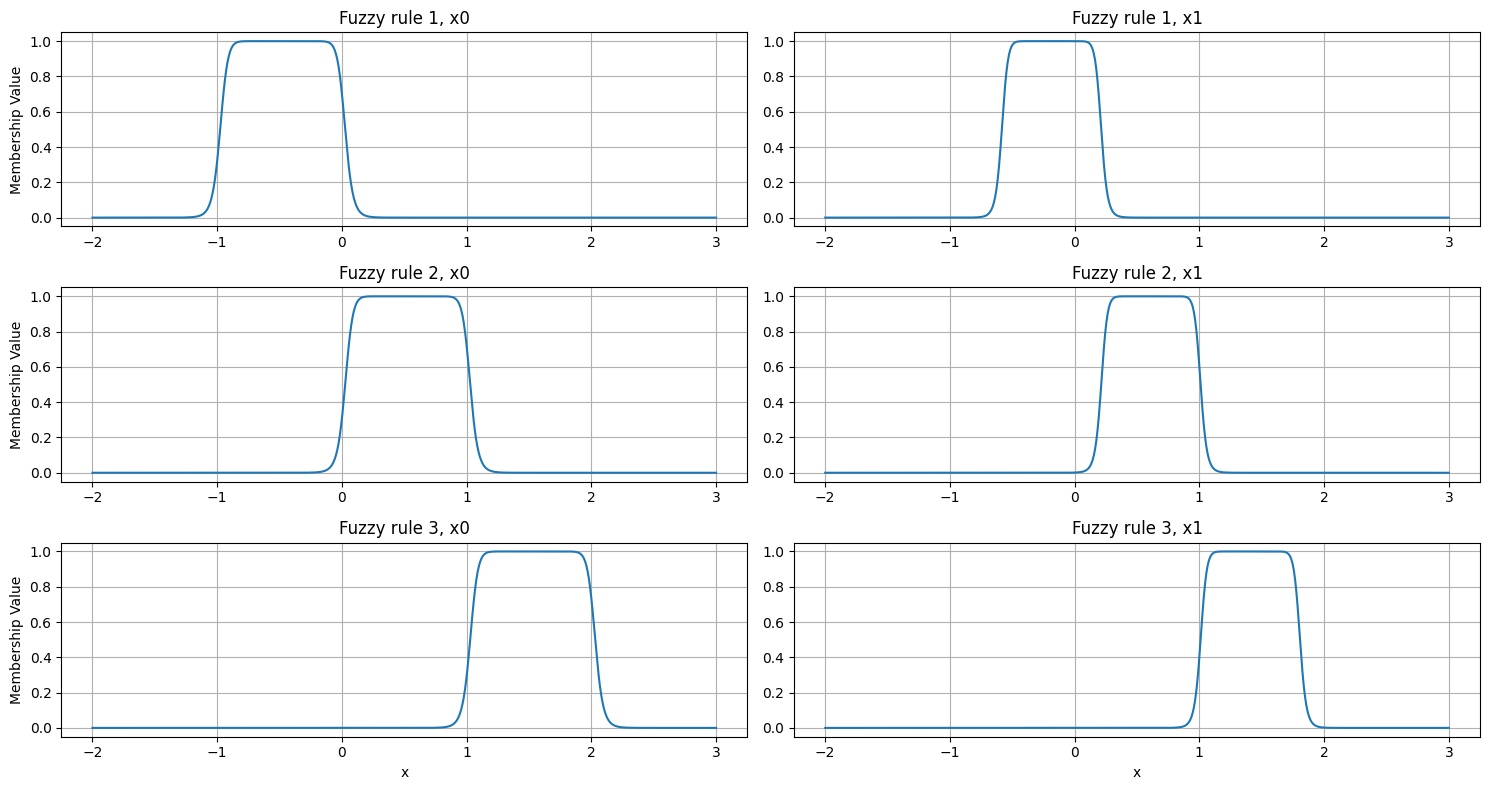

In [129]:
anfis.plot_premises

In [130]:
anfis.predict(x_train)

array([[-0.6293159 ],
       [-0.9710208 ],
       [-0.73069626],
       [-0.52857065],
       [-0.5836736 ]], dtype=float32)

In [131]:
anfis.intermediate_values(x_train)

(tensor([[2.3141e-10, 1.5165e-05, 9.9389e-01, 4.8213e-12, 3.1596e-07, 2.0707e-02,
          1.3454e-18, 8.8173e-14, 5.7786e-09],
         [1.8895e-02, 2.8831e-07, 4.3993e-12, 9.9481e-01, 1.5179e-05, 2.3162e-10,
          1.1140e-07, 1.6999e-12, 2.5938e-17],
         [7.0797e-01, 8.9775e-05, 4.5887e-10, 3.0172e-01, 3.8260e-05, 1.9556e-10,
          1.7476e-08, 2.2161e-12, 1.1327e-17],
         [2.2459e-18, 1.7598e-11, 2.2147e-10, 1.4719e-13, 1.1533e-06, 1.4514e-05,
          9.6462e-09, 7.5584e-02, 9.5119e-01],
         [3.9813e-07, 9.9998e-01, 1.7260e-03, 6.0749e-12, 1.5258e-05, 2.6336e-08,
          9.2696e-17, 2.3283e-10, 4.0186e-13]]),
 tensor([[2.2808e-10, 1.4947e-05, 9.7958e-01, 4.7518e-12, 3.1141e-07, 2.0409e-02,
          1.3261e-18, 8.6903e-14, 5.6954e-09],
         [1.8639e-02, 2.8440e-07, 4.3397e-12, 9.8135e-01, 1.4974e-05, 2.2849e-10,
          1.0990e-07, 1.6769e-12, 2.5587e-17],
         [7.0108e-01, 8.8901e-05, 4.5440e-10, 2.9879e-01, 3.7888e-05, 1.9366e-10,
          1.7

In [132]:
anfis.fuzzy_rules, anfis.rules

(3, 9)

#### 1 output, binary

In [133]:
x_train = torch.randn(5, 2)

In [134]:
anfis2 = ANFIS(x_train,
               init_fuzzy_rules=2,
               membership_function=GeneralizedBell_MF,
               consequent_function=Linear_CF,
               premises_init_mode=0,
               outputs=1,
               output_type='binary',
               restricted=False)

In [135]:
anfis2.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
Fuzzy rule 1,1.563703,8.0,-2.290902,1.079672,8.0,-0.952216
Fuzzy rule 2,1.563703,8.0,0.836503,1.079672,8.0,1.207127


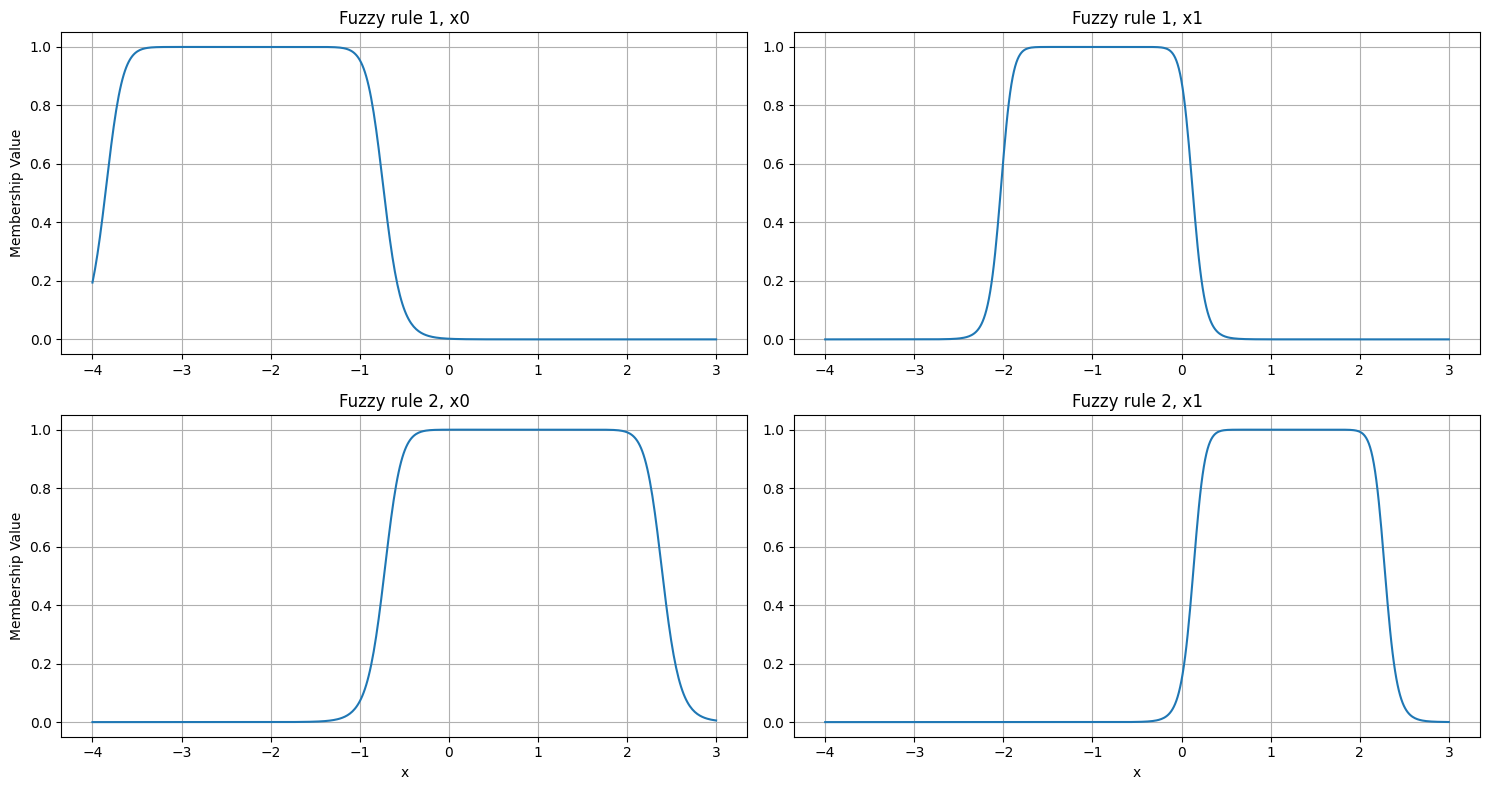

In [136]:
anfis2.plot_premises

In [137]:
anfis2(x_train)

tensor([[0.6495],
        [0.4999],
        [0.5912],
        [0.5960],
        [0.6161]], grad_fn=<SigmoidBackward0>)

In [138]:
anfis2.predict(x_train)

array([[1],
       [0],
       [1],
       [1],
       [1]])

In [139]:
anfis2.fuzzy_rules, anfis2.rules

(2, 4)

#### + outputs, multiclass

In [140]:
x_train = torch.randn(5, 3)
x_train

tensor([[ 0.8452,  0.8777,  0.4709],
        [-0.7214,  2.0084, -0.9907],
        [ 0.6487, -1.4330, -0.7191],
        [ 1.3906,  0.5468,  2.1690],
        [-0.6212,  1.5133, -0.6569]])

In [141]:
anfis3 = ANFIS(x_train,
               init_fuzzy_rules=2,
               membership_function=GeneralizedBell_MF,
               consequent_function=Linear_CF,
               premises_init_mode=0,
               outputs=3,
               output_type='multiclass',
               restricted=False)

In [142]:
anfis3(x_train)

tensor([[0.2885, 0.6379, 0.0736],
        [0.6071, 0.1137, 0.2792],
        [0.7322, 0.2463, 0.0214],
        [0.5208, 0.3620, 0.1172],
        [0.4923, 0.1307, 0.3770]], grad_fn=<SoftmaxBackward0>)

In [143]:
anfis3.intermediate_values(x_train)

(tensor([[1.2477e-05, 3.8507e-06, 1.4060e-03, 4.3393e-04, 6.8811e-03, 2.1237e-03,
          7.7542e-01, 2.3931e-01],
         [1.5259e-05, 2.3282e-10, 1.0000e+00, 1.5259e-05, 2.3282e-10, 3.5526e-15,
          1.5259e-05, 2.3282e-10],
         [1.5272e-02, 9.8164e-07, 2.3303e-07, 1.4978e-11, 9.9649e-01, 6.4052e-05,
          1.5205e-05, 9.7734e-10],
         [2.2319e-11, 1.4627e-06, 2.1689e-10, 1.4214e-05, 1.4627e-06, 9.5864e-02,
          1.4214e-05, 9.3156e-01],
         [1.8312e-04, 1.6677e-08, 1.0000e+00, 9.1074e-05, 6.0823e-09, 5.5394e-13,
          3.3215e-05, 3.0250e-09]]),
 tensor([[1.2166e-05, 3.7546e-06, 1.3709e-03, 4.2310e-04, 6.7094e-03, 2.0707e-03,
          7.5607e-01, 2.3334e-01],
         [1.5258e-05, 2.3281e-10, 9.9995e-01, 1.5258e-05, 2.3281e-10, 3.5524e-15,
          1.5258e-05, 2.3281e-10],
         [1.5093e-02, 9.7015e-07, 2.3030e-07, 1.4803e-11, 9.8483e-01, 6.3302e-05,
          1.5027e-05, 9.6590e-10],
         [2.1723e-11, 1.4237e-06, 2.1109e-10, 1.3834e-05, 1.42

In [144]:
anfis3.predict(x_train)

array([[1],
       [0],
       [0],
       [0],
       [0]])

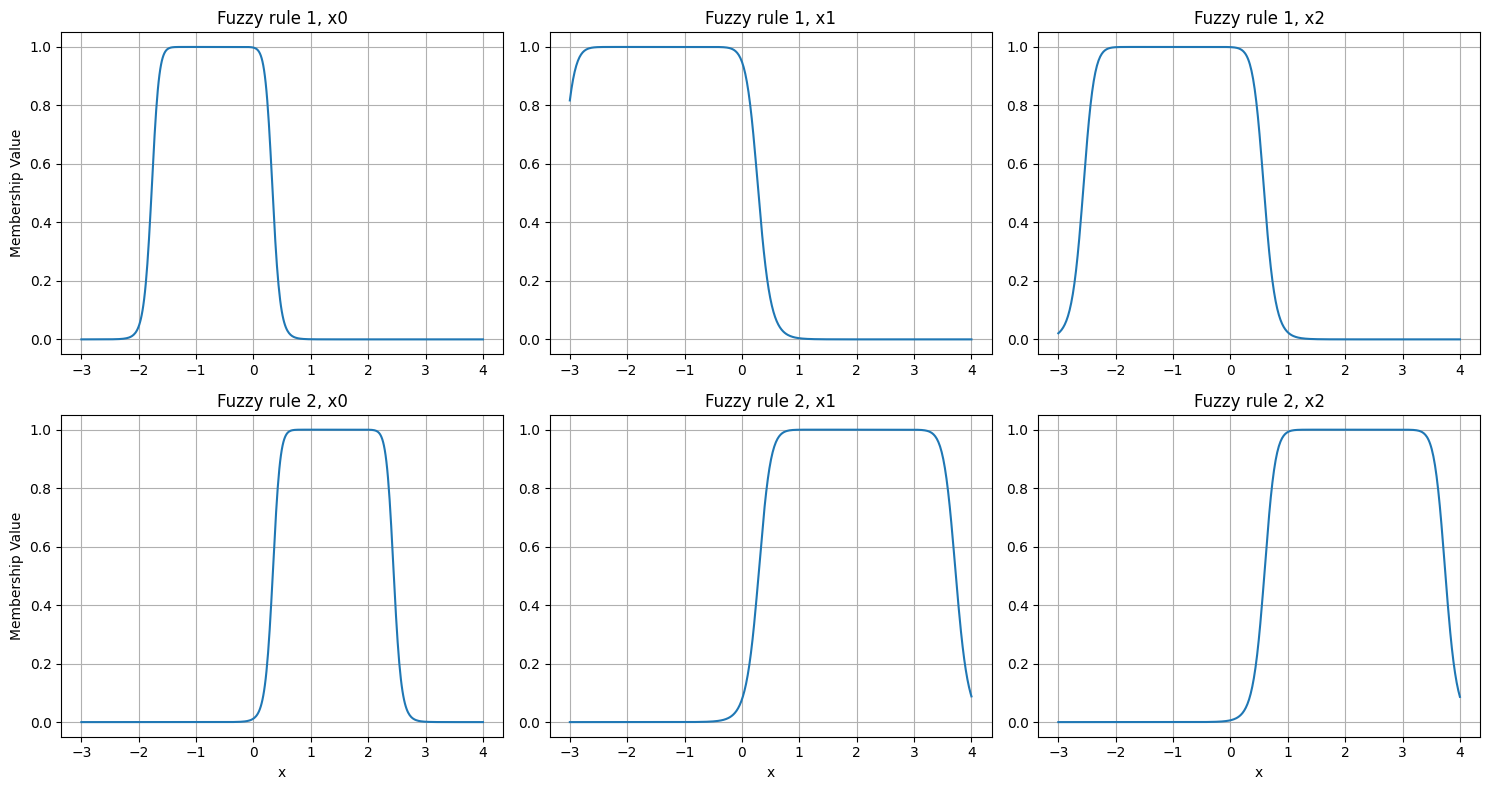

In [145]:
anfis3.plot_premises

In [146]:
anfis3.fuzzy_rules, anfis3.rules

(2, 8)

### rANFIS

#### 1 output, regression

In [147]:
r_anfis = ANFIS(x_train,
                init_fuzzy_rules=3,
                membership_function=GeneralizedBell_MF,
                consequent_function=Linear_CF,
                premises_init_mode=0,
                outputs=1,
                output_type='regression',
                restricted=True)

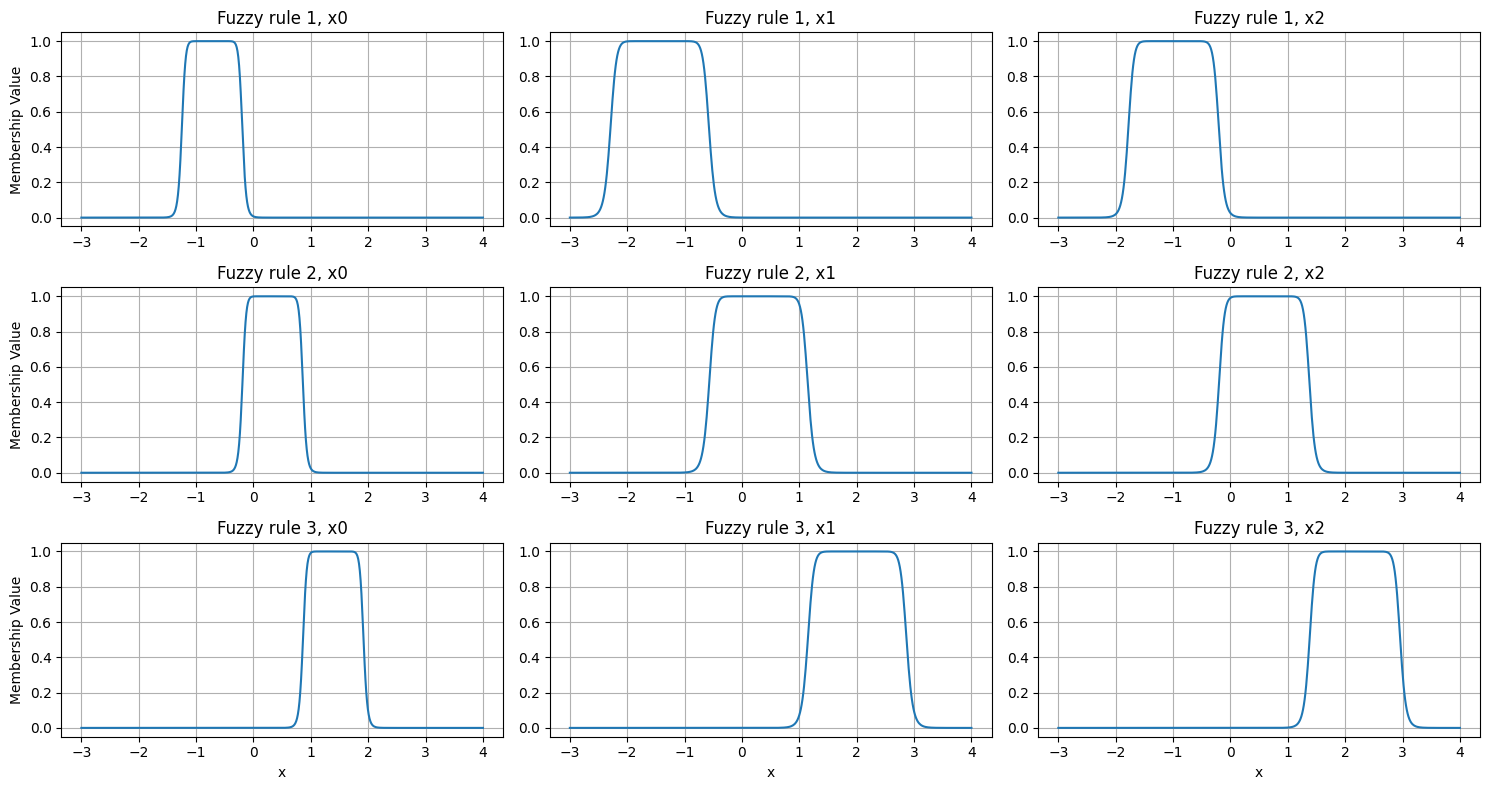

In [148]:
r_anfis.plot_premises

In [149]:
r_anfis(x_train)

tensor([[-0.4299],
        [ 0.1337],
        [ 2.2214],
        [-2.2591],
        [ 0.1421]], grad_fn=<TBackward0>)

In [150]:
r_anfis.predict(x_train)

array([[-0.42991155],
       [ 0.13367684],
       [ 2.2214274 ],
       [-2.2591498 ],
       [ 0.14211003]], dtype=float32)

In [151]:
r_anfis.intermediate_values(x_train)

(tensor([[2.0035e-19, 6.2931e-01, 2.2367e-08],
         [2.3283e-10, 3.5526e-15, 5.4210e-20],
         [2.3664e-07, 4.7606e-09, 9.8493e-22],
         [8.7705e-26, 2.3282e-10, 2.0766e-04],
         [2.7947e-09, 1.7732e-10, 7.0430e-19]]),
 tensor([[3.1837e-19, 1.0000e+00, 3.5543e-08],
         [9.9998e-01, 1.5258e-05, 2.3283e-10],
         [9.8028e-01, 1.9720e-02, 4.0800e-15],
         [4.2235e-22, 1.1212e-06, 1.0000e+00],
         [9.4034e-01, 5.9662e-02, 2.3698e-10]]))

In [152]:
r_anfis.fuzzy_rules, r_anfis.rules

(3, 3)

#### 1 output, binary

In [153]:
r_anfis2 = ANFIS(x_train,
                init_fuzzy_rules=2,
                membership_function=GeneralizedBell_MF,
                consequent_function=Linear_CF,
                premises_init_mode=1,
                outputs=1,
                output_type='binary',
                restricted=True)

In [154]:
r_anfis2(x_train)

tensor([[0.7298],
        [0.7372],
        [0.4456],
        [0.7762],
        [0.6506]], grad_fn=<SigmoidBackward0>)

In [155]:
r_anfis2.predict(x_train)

array([[1],
       [1],
       [0],
       [1],
       [1]])

In [156]:
r_anfis2.fuzzy_rules, r_anfis2.rules

(2, 2)

#### + outputs, multiclass

In [157]:
r_anfis3 = ANFIS(x_train,
                init_fuzzy_rules=3,
                membership_function=GeneralizedBell_MF,
                consequent_function=Linear_CF,
                premises_init_mode=0,
                outputs=3,
                output_type='multiclass',
                restricted=True)

In [158]:
r_anfis3(x_train)

tensor([[0.6064, 0.2751, 0.1185],
        [0.0616, 0.0342, 0.9042],
        [0.1263, 0.8010, 0.0727],
        [0.0640, 0.0743, 0.8616],
        [0.1483, 0.0739, 0.7778]], grad_fn=<SoftmaxBackward0>)

In [159]:
r_anfis3.predict(x_train)

array([[0],
       [2],
       [1],
       [2],
       [2]])

In [160]:
r_anfis3.fuzzy_rules, r_anfis3.rules

(3, 3)

# Training Algorithm Structures

## EarlyStopping

In [161]:
class EarlyStopping():
    def __init__(self, patience, delta=0, last_state=False):
        #Parameters
        self.patience = patience
        self.delta = delta
        self.last_state = last_state # True if the last state is the one to be restored (not the best one)
        
        #For running
        self._counter = 0
        self._best_loss = None
        self._best_premises = None
        self._best_consequents = None
        self._early_stop = False

    def __call__(self, loss, ANFISmodel):
        if self._best_loss is None:
            self._best_loss = loss
            self._best_premises = ANFISmodel.get_premises()
            self._best_consequents = ANFISmodel.get_consequents()

        elif loss + self._delta > self._best_loss:
            self._counter += 1
            if self._counter >= self._patience:
                self._early_stop = True
                if self._last_state == False:
                    ANFISmodel.set_premises(self._best_premises)
                    ANFISmodel.set_consequents(self._best_consequents)

        else:
            self._best_loss = loss
            self._best_premises = ANFISmodel.get_premises()
            self._best_consequents = ANFISmodel.get_consequents()
            self._counter = 0

    def reset(self):
        self._counter = 0
        self._best_loss = None
        self._best_premises = None
        self._best_consequents = None
        self._early_stop = False

## Training Structures

In [162]:
class ANFISTrainer():
    def __init__(self, epochs, loss_function, validation=0, early_stopping=None):
        # Hyperparameters
        self.epochs = epochs
        self.loss_function = loss_function

        # History
        self.history = {'loss': np.array()}
        self.val_history = {'loss': np.array()}
        
        # Early stopping
        self.validation = validation
        self.early_stop = early_stopping
    
    
    def __call__(self, ANFISmodel, loader, verbose=True):
        train_loader, val_loader = self.train_val_split(loader)
        
        _ = self._register_measures(ANFISmodel, train_loader, val_loader)

        ep = 0
        while ep < self.epochs:
            
            self._premises_update()
            self._consequents_update()
            
            loss = self._register_measures(ANFISmodel, train_loader, val_loader)
            if self.early_stop is not None:
                self.early_stop(loss, ANFISmodel)
                if self.early_stop._early_stop:
                    break
                
            if verbose:
                print(f'Epoch: {ep+1}/{self.epochs} - Loss: {loss}')
            
            ep += 1
        
        if verbose:
            print('Training finished')
    
    
    @abstractmethod
    def _consequents_update(self, ANFISmodel, loader):
        pass
        
    
    @abstractmethod
    def _premises_update(self, ANFISmodel, loader):
        pass
    
    
    def _train_val_split(self, train_loader):
        val_loader = None
        
        if self.validation != 0:
            x_train, y_train = train_loader.dataset.tensors
            x_train, x_val, y_train, y_val = train_test_split(x_train.numpy(), y_train.numpy(), test_size=self.validation, shuffle=True)
            x_train, x_val, y_train, y_val = torch.from_numpy(x_train), torch.from_numpy(x_val), torch.from_numpy(y_train), torch.from_numpy(y_val)
            
            train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size=train_loader.batch_size, shuffle=True)
            val_loader = data.DataLoader(data.TensorDataset(x_val, y_val), batch_size=train_loader.batch_size, shuffle=False)

        return train_loader, val_loader


    def get_measures(self, ANFISmodel, x, y):
        measures = {}
        y = y.numpy()
        pred = ANFISmodel.predict(x)

        if isinstance(ANFISmodel._output_layer._last_layer, nn.Identity):
            measures['loss'] = self.loss_function(torch.tensor(y), ANFISmodel(x)).item()
            measures['MSE'] = mean_squared_error(y, pred).item()
            measures['RMSE'] = root_mean_squared_error(y, pred).item()
            measures['MAE'] = mean_absolute_error(y, pred).item()
            measures['R2'] = r2_score(y, pred)
            measures['MAPE'] = mean_absolute_percentage_error(y, pred).item()

        elif isinstance(ANFISmodel._output_layer._last_layer, nn.Sigmoid):
            measures['loss'] = self.loss_function(torch.tensor(y), ANFISmodel(x)).item()
            measures['Accuracy'] = accuracy_score(y, pred)
            measures['Precision'] = precision_score(y, pred).item()
            measures['Recall'] = recall_score(y, pred).item()
            measures['F1'] = f1_score(y, pred).item()
            measures['Confusion Matrix'] = confusion_matrix(y, pred)

        elif isinstance(ANFISmodel._output_layer._last_layer, nn.Softmax):
            measures['loss'] = self.loss_function(torch.tensor(y), ANFISmodel(x)).item()
            measures['Accuracy'] = accuracy_score(y, pred)
            measures['Precision'] = precision_score(y, pred, average='weighted', zero_division=0).item()
            measures['Recall'] = recall_score(y, pred, average='weighted', zero_division=0).item()
            measures['F1'] = f1_score(y, pred, average='weighted', zero_division=0).item()
            measures['Confusion Matrix'] = confusion_matrix(y, pred, labels=list(range(ANFISmodel._outputs)))

        return measures
    
    
    def _register_measures(self, ANFISmodel, train_loader, val_loader):
        # Validation set
        if val_loader is not None:
            x_val, y_val = val_loader.dataset.tensors
            measures = self.get_measures(ANFISmodel, x_val, y_val)
            
            for measure in measures.keys():
                if measure not in self.val_history:
                    self.val_history[measure] = np.array([])
                np.append(self.val_history[measure], measures[measure])
    
                
        # Training set
        x_train, y_train = train_loader.dataset.tensors
        measures = self.get_measures(ANFISmodel, x_train, y_train)
        
        for measure in measures.keys():
            if measure not in self.history:
                self.history[measure] = np.array([])
            np.append(self.history[measure], measures[measure])
            
            
        # return loss
        if val_loader is not None:
            return self.val_history['loss'][-1]
        return self.history['history'][-1]

In [163]:
torch.tensor(1)

tensor(1)

In [164]:
class OLS(ANFISTrainer): #Ordinary Least Squares
    def __init__(self, epochs, loss_function, gamma=0.01, validation=0, early_stopping=None):
        # Llama al constructor de la clase abstracta para inicializar los atributos comunes
        super().__init__(epochs, loss_function, validation, early_stopping)
        # Inicializa atributos específicos de la clase derivada
        self.gamma = gamma
        
    def _consequents_update(self, ANFISmodel, loader):
        x_train, y_train = loader.dataset.tensors
        
        current_consequents = ANFISmodel.get_consequents()
        new_consequents = torch.zeros(current_consequents.shape, dtype=x_train.dtype)
        
        _, w_norm, _ = ANFISmodel.intermediate_values(x_train)
        xe = torch.cat((x_train, torch.ones(x_train.shape[0], 1)), dim=1)
        
        fs = w_norm.unsqueeze(2).repeat(1, 1, xe.shape[1]).view(w_norm.shape[0], -1)
        X = xe.repeat(1, ANFISmodel.rules)
        
        for i in range(ANFISmodel.outputs):
            flat_consequents, _, _, _ = torch.linalg.lstsq(fs * X, y_train[:, i])
            new_consequents[i] = torch.reshape(flat_consequents, (ANFISmodel.rules, xe.shape[1]))
        
        
    
    def _premises_update(self):
        return "premises_update"

In [165]:
ols = OLS(epochs=100,
          validation=0.2,
          loss_function=nn.functional.mse_loss)

ols.history[0] = 0.5
ols.history[1] = 1
ols.history

TypeError: array() missing required argument 'object' (pos 0)

In [119]:
x_train = torch.randn(10, 2)
y_train = torch.randn(10, 1)
y_train_binary = torch.randint(0, 2, (10, 1))
y_train_multiclass = torch.randint(0, 3, (10, 1)) # 3 clases
train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size=2, shuffle=True)

In [106]:
y_train_multiclass.numpy()

array([[1],
       [2],
       [0],
       [1],
       [2],
       [1],
       [2],
       [2],
       [1],
       [1]])

In [107]:
y_train_binary.numpy()

array([[0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]])

In [108]:
y_train.numpy()

array([[-0.27968526],
       [ 0.84244514],
       [ 0.4711214 ],
       [ 1.1070977 ],
       [ 1.009855  ],
       [-1.6744822 ],
       [ 0.16516085],
       [-2.483041  ],
       [-1.508123  ],
       [-0.47712177]], dtype=float32)

In [ ]:
x_train, y_train

In [109]:
for batch_idx, (data1, target) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}:")
    print("Data:", data1)
    print("Target:", target)
    print()

Batch 1:
Data: tensor([[ 0.0781, -0.0179],
        [-0.4452,  1.6722]])
Target: tensor([[-1.6745],
        [-1.5081]])

Batch 2:
Data: tensor([[ 2.1946,  0.0413],
        [-0.5287, -0.2638]])
Target: tensor([[1.1071],
        [0.8424]])

Batch 3:
Data: tensor([[-2.3843, -0.3087],
        [ 1.0552,  1.1427]])
Target: tensor([[ 0.1652],
        [-0.4771]])

Batch 4:
Data: tensor([[-1.7624,  0.2469],
        [ 0.8289,  1.0893]])
Target: tensor([[-2.4830],
        [ 0.4711]])

Batch 5:
Data: tensor([[-0.8120, -0.1818],
        [ 0.9128, -0.5009]])
Target: tensor([[ 1.0099],
        [-0.2797]])



In [110]:
train_loader.dataset.tensors

(tensor([[ 0.9128, -0.5009],
         [-0.5287, -0.2638],
         [ 0.8289,  1.0893],
         [ 2.1946,  0.0413],
         [-0.8120, -0.1818],
         [ 0.0781, -0.0179],
         [-2.3843, -0.3087],
         [-1.7624,  0.2469],
         [-0.4452,  1.6722],
         [ 1.0552,  1.1427]]),
 tensor([[-0.2797],
         [ 0.8424],
         [ 0.4711],
         [ 1.1071],
         [ 1.0099],
         [-1.6745],
         [ 0.1652],
         [-2.4830],
         [-1.5081],
         [-0.4771]]))

In [111]:
train_data, val_data = ols.train_val_split(train_loader)

In [112]:
train_data.dataset.tensors

(tensor([[ 0.0781, -0.0179],
         [-0.4452,  1.6722],
         [-0.5287, -0.2638],
         [ 2.1946,  0.0413],
         [-1.7624,  0.2469],
         [ 1.0552,  1.1427],
         [-2.3843, -0.3087],
         [ 0.8289,  1.0893]]),
 tensor([[-1.6745],
         [-1.5081],
         [ 0.8424],
         [ 1.1071],
         [-2.4830],
         [-0.4771],
         [ 0.1652],
         [ 0.4711]]))

In [94]:
val_data.dataset.tensors

(tensor([[-0.8157,  0.4016],
         [ 0.7555, -1.1555]]),
 tensor([[ 3.1526],
         [-1.3932]]))

In [120]:
test_anfis = ANFIS(x_train,
                   init_fuzzy_rules=2, 
                   membership_function=GeneralizedBell_MF, 
                   consequent_function=Linear_CF, 
                   premises_init_mode=0, 
                   outputs=1, 
                   output_type='regression',
                   restricted=True)

test_anfis._output_layer._last_layer

Identity()

In [121]:
test_anfis.predict(x_train)

array([[ 0.29298973],
       [ 0.4414063 ],
       [ 0.40004286],
       [ 0.86017334],
       [-0.5365299 ],
       [ 0.64252335],
       [ 0.07219921],
       [ 1.0621393 ],
       [ 0.11241124],
       [ 0.86058646]], dtype=float32)

In [122]:
ols.get_measures(test_anfis, x_train, y_train)

{'loss': 1.1982135772705078,
 'MSE': 1.1982134580612183,
 'RMSE': 1.0946294069290161,
 'MAE': 0.9032529592514038,
 'R2': 0.11173909902572632,
 'MAPE': 2.0981313812711497}